In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile

# 🔹 Allow loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

image_size = (256, 256)
batch_size = 32

# Data augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Base directory for the new dataset
base_dataset_path = '/content/drive/MyDrive/Split Dataset'

# Create data generators using the new path
train_generator = train_datagen.flow_from_directory(
    f'{base_dataset_path}/Train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True # Shuffle training data
)

validation_generator = val_test_datagen.flow_from_directory(
    f'{base_dataset_path}/Validation',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle validation data for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_dataset_path}/Test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle test data for consistent evaluation
)

print("\nData generators created successfully using new dataset path!")
print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")


Found 3500 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.

Data generators created successfully using new dataset path!
Number of training samples: 3500
Number of validation samples: 1000
Number of test samples: 500
Classes: {'BlackPoint': 0, 'FusariumFootRot': 1, 'HealthyLeaf': 2, 'LeafBlight': 3, 'WheatBlast': 4}


In [5]:
import json

with open("wheat_class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [6]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

# Get the number of classes from the train_generator
num_classes = len(train_generator.class_indices)

model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=[256,256,3]))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(Conv2D(512, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Dropout(0.25))

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))

model.add(Dropout(0.4))

model.add(Dense(units=num_classes,activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,844,837 (18.48 MB)

 Trainable params: 4,844,837 (18.48 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
training_history = model.fit(x=train_generator,validation_data=validation_generator,epochs=50,verbose=1)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2667s 24s/step - accuracy: 0.3849 - loss: 1.3447 - val_accuracy: 0.6500 - val_loss: 0.8775
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6734 - loss: 0.8173 - val_accuracy: 0.6990 - val_loss: 0.6951
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7549 - loss: 0.6574 - val_accuracy: 0.7960 - val_loss: 0.5147
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.7874 - loss: 0.5825 - val_accuracy: 0.7120 - val_loss: 0.7064
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8183 - loss: 0.5028 - val_accuracy: 0.8580 - val_loss: 0.3267
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8334 - loss: 0.4452 - val_accuracy: 0.8900 - val_loss: 0.2851
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8554 - loss: 0.4026 - val_accuracy: 0.8950 - val_loss: 0.2797
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8874 - loss: 0.3272 - val_ac

In [10]:
import json

history_dict = training_history.history

with open("wheat_training_history.json", "w") as f:
    json.dump(history_dict, f)

Model saved successfully as 'cnn_model3.h5'

Final Training Accuracy: 0.9863
Final Validation Accuracy: 0.9510


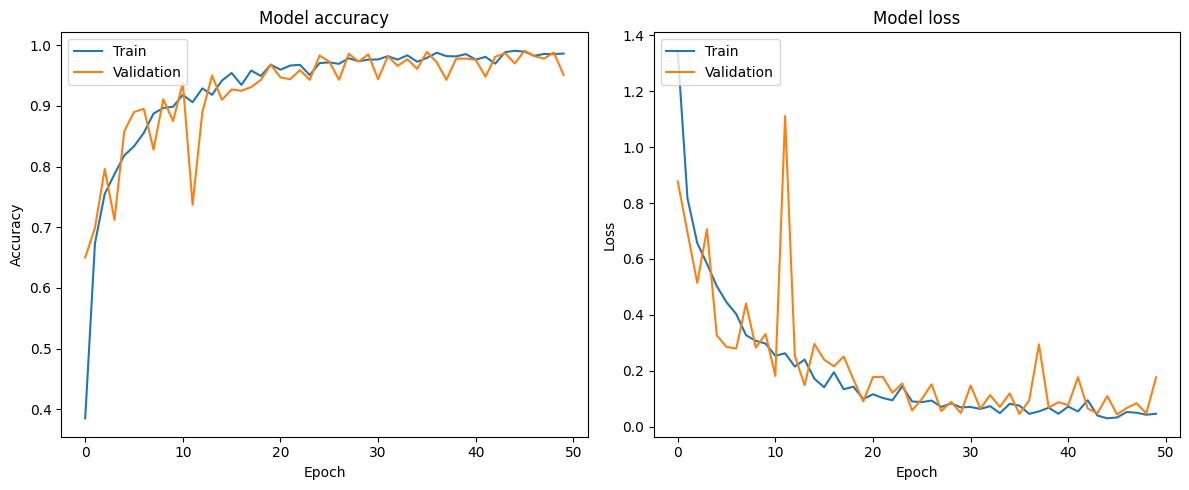

In [11]:
import matplotlib.pyplot as plt

# 1. Save the model
model.save('cnn_model_2.h5')
print("Model saved successfully as 'cnn_model3.h5'")

# 2. Print accuracy
print(f"\nFinal Training Accuracy: {training_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {training_history.history['val_accuracy'][-1]:.4f}")

# 3. Visualize accuracy
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 333s 22s/step

Classification Report:
                 precision    recall  f1-score   support

     BlackPoint     0.9126    0.9400    0.9261       100
FusariumFootRot     0.9346    1.0000    0.9662       100
    HealthyLeaf     1.0000    0.8600    0.9247       100
     LeafBlight     1.0000    0.9800    0.9899       100
     WheatBlast     0.9434    1.0000    0.9709       100

       accuracy                         0.9560       500
      macro avg     0.9581    0.9560    0.9556       500
   weighted avg     0.9581    0.9560    0.9556       500



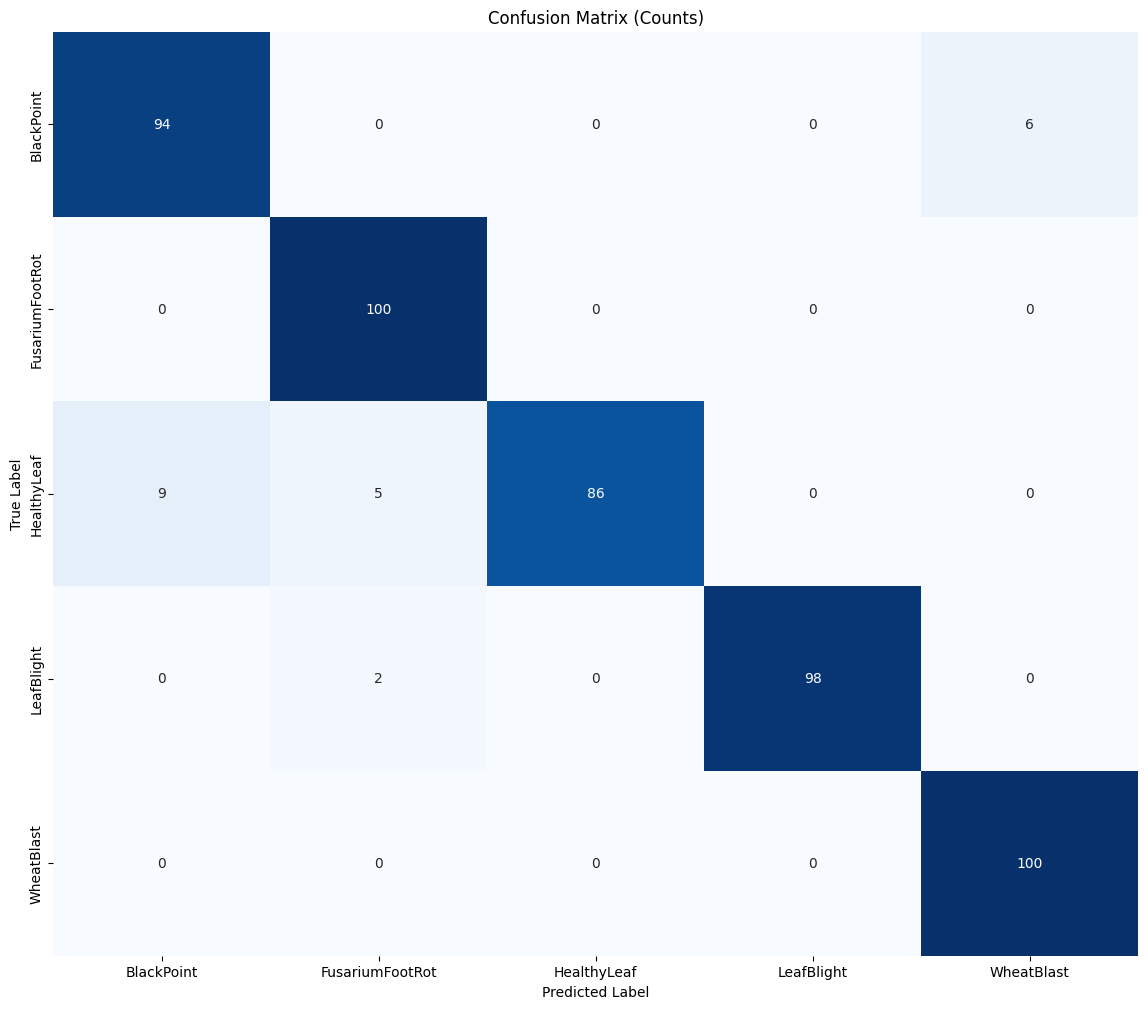

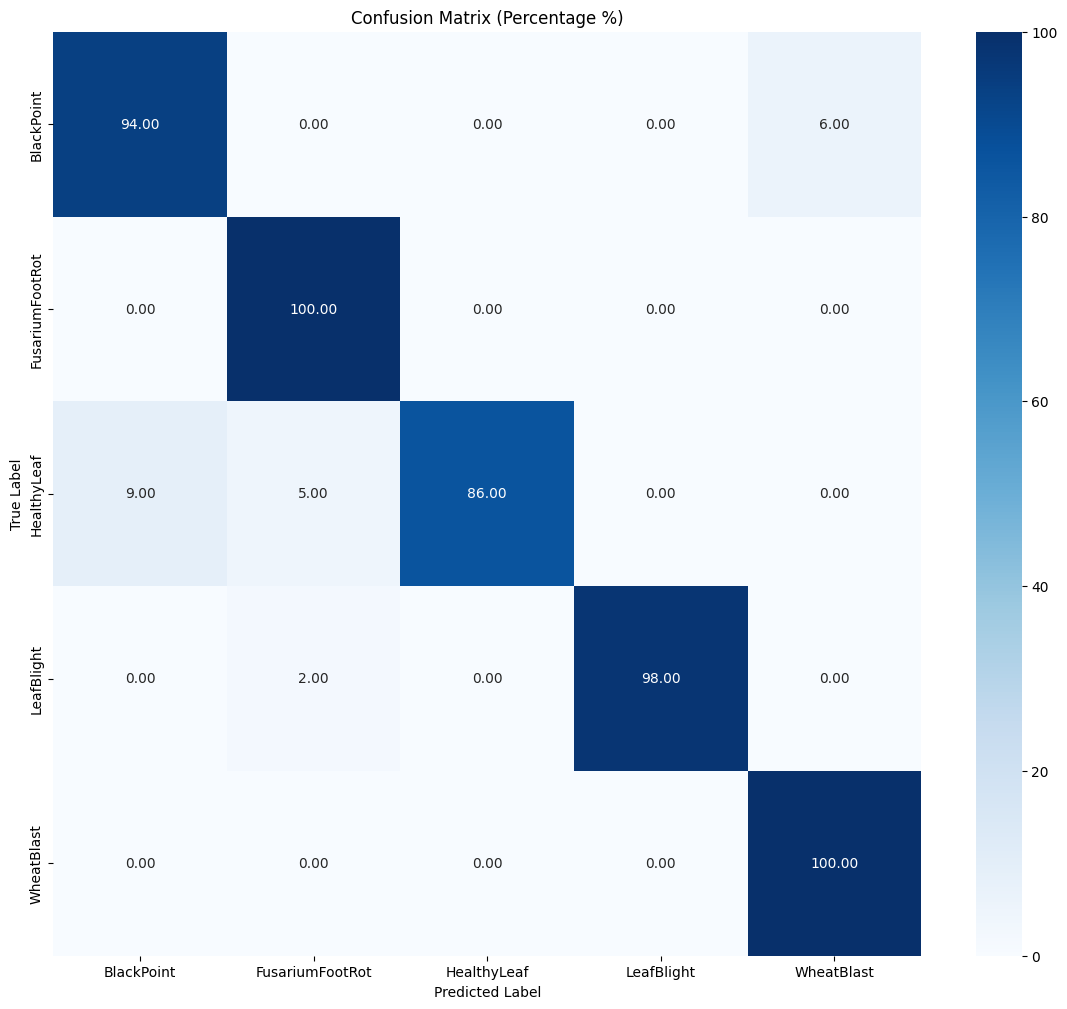

In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Predict on the test data
# -----------------------------
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # convert to %

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix as Percentages
plt.figure(figsize=(14, 12))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Confusion Matrix (Percentage %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
model.save('wheat_cnn_model_2.keras')

In [15]:
from google.colab import files

# Download the saved model file
files.download('wheat_cnn_model_2.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>